Name: Eric Baah
Course: MAT 443
Homework 6
Date: 10/26/2024

Question 4.13

In [140]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from ISLP import load_data
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings



              Year         Lag1         Lag2         Lag3         Lag4  \
count  1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
mean   2000.048669     0.150585     0.151079     0.147205     0.145818   
std       6.033182     2.357013     2.357254     2.360502     2.360279   
min    1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%    1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%    2000.000000     0.241000     0.241000     0.241000     0.238000   
75%    2005.000000     1.405000     1.409000     1.409000     1.409000   
max    2010.000000    12.026000    12.026000    12.026000    12.026000   

              Lag5       Volume        Today  
count  1089.000000  1089.000000  1089.000000  
mean      0.139893     1.574618     0.149899  
std       2.361285     1.686636     2.356927  
min     -18.195000     0.087465   -18.195000  
25%      -1.166000     0.332022    -1.154000  
50%       0.234000     1.002680     0.241000  
75% 

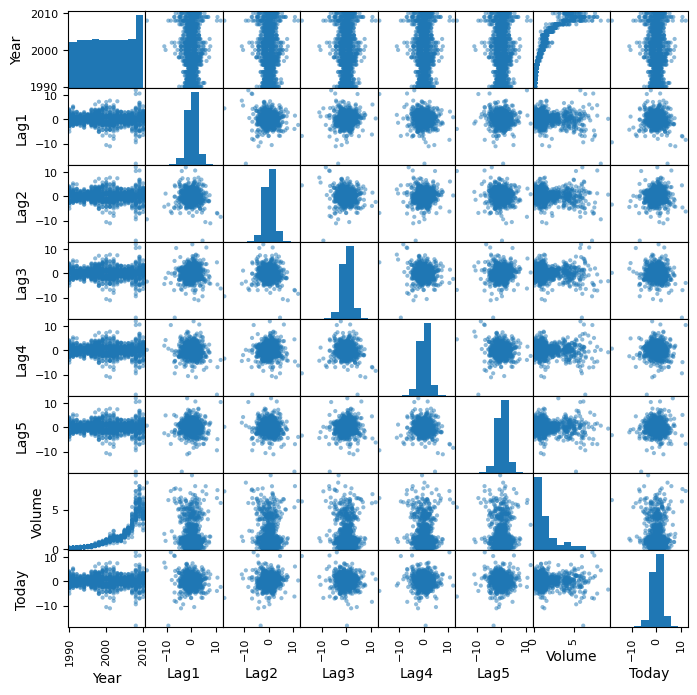

In [141]:
# Load the dataset
data=load_data("Weekly")

# Part (a): Numerical and graphical summaries of the Weekly data
print(data.describe())

# Plotting a pairplot for visual inspection
pd.plotting.scatter_matrix(data, figsize=(8, 8))
plt.show()


There is a positive trend between Year and Volume but not as clear relationship between the Lags. There is also no clear correlation between Year and Lag1, Lag2, Lag3, Lag4 and Lag5.

In [142]:

# Part (b): Logistic regression with 'Direction' as the response
data['Direction'] = data['Direction'].apply(lambda x:1 if x=='Up' else 0)

# Prepare the predictors (Lag1 to Lag5 and Volume)
X = data[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = data['Direction']

X = sm.add_constant(X)

# Split into train (1990-2008) and test (2009-2010)
train = data[data['Year'] < 2009]
test = data[data['Year'] >= 2009]

X_train = train[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y_train = train['Direction']
X_test = test[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y_test = test['Direction']

# Fit logistic regression model
Log_Model = sm.Logit(y, X)
Result = Log_Model.fit()
print(Result.summary())


Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sun, 27 Oct 2024   Pseudo R-squ.:                0.006580
Time:                        00:49:02   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

Some of the predictors appear to be statistically significant. It is only the Lag2 predictor that is statistically significant. all the other predictors are not statistically significant.

In [143]:
# Part (c)

# Predict probabilities on the test set
Log_prob = Result.predict(X)  # Get probabilities for the 'Up' class

# Set prediction threshold at 0.5
y_pred = np.where(Log_prob > 0.5, 1, 0)

# Confusion matrix and accuracy
conf_matrix = confusion_matrix(y, y_pred)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_df = pd.DataFrame(conf_matrix, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix:\n", conf_matrix_df)

accuracy = accuracy_score(y, y_pred)
print("Accuracy: ", accuracy)


Confusion Matrix:
             Pred: Down  Pred: Up
True: Down          54       430
True: Up            48       557
Accuracy:  0.5610651974288338


The confusion matrix shows that the model predicted the stock price to go 'Up' 430 times when it actually went 'Down' and predicted the prices to go 'Down' 48 times when it actually went 'Up'

In [144]:

# Part (d): Logistic regression with Lag2 as the only predictor
X_train_lag2 = train[['Lag2']]
X_test_lag2 = test[['Lag2']]

log_reg_lag2 = LogisticRegression(solver='liblinear')
log_reg_lag2.fit(X_train_lag2, y_train)
y_pred_lag2 = log_reg_lag2.predict(X_test_lag2)

# Confusion matrix and accuracy for Lag2-only model
conf_matrix_lag2 = confusion_matrix(y_test, y_pred_lag2)
accuracy_lag2 = accuracy_score(y_test, y_pred_lag2)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_lag2_df = pd.DataFrame(conf_matrix_lag2, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (Lag2 only):\n", conf_matrix_lag2_df)
print("Accuracy (Lag2 only): ", accuracy_lag2)


Confusion Matrix (Lag2 only):
             Pred: Down  Pred: Up
True: Down           9        34
True: Up             5        56
Accuracy (Lag2 only):  0.625


In [145]:

# Part (e): LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_lag2, y_train)
y_pred_lda = lda.predict(X_test_lag2)

# Confusion matrix and accuracy for LDA
conf_matrix_lda = confusion_matrix(y_test, y_pred_lda)
accuracy_lda = accuracy_score(y_test, y_pred_lda)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_lda_df = pd.DataFrame(conf_matrix_lda, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (LDA):\n", conf_matrix_lda_df)
print("Accuracy (LDA): ", accuracy_lda)


Confusion Matrix (LDA):
             Pred: Down  Pred: Up
True: Down           9        34
True: Up             5        56
Accuracy (LDA):  0.625


In [146]:

# Part (f): QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_lag2, y_train)
y_pred_qda = qda.predict(X_test_lag2)

# Confusion matrix and accuracy for QDA
conf_matrix_qda = confusion_matrix(y_test, y_pred_qda)
accuracy_qda = accuracy_score(y_test, y_pred_qda)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_qda_df = pd.DataFrame(conf_matrix_qda, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (QDA):\n", conf_matrix_qda_df)
print("Accuracy (QDA): ", accuracy_qda)


Confusion Matrix (QDA):
             Pred: Down  Pred: Up
True: Down           0        43
True: Up             0        61
Accuracy (QDA):  0.5865384615384616


In [147]:

# Part (g): KNN with K=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_lag2, y_train)
y_pred_knn = knn.predict(X_test_lag2)

# Confusion matrix and accuracy for KNN
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_knn_df = pd.DataFrame(conf_matrix_knn, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (KNN):\n", conf_matrix_knn_df)
print("Accuracy (KNN): ", accuracy_knn)


Confusion Matrix (KNN):
             Pred: Down  Pred: Up
True: Down          22        21
True: Up            31        30
Accuracy (KNN):  0.5


In [148]:

# Part (h): Naive Bayes
nb = GaussianNB()
nb.fit(X_train_lag2, y_train)
y_pred_nb = nb.predict(X_test_lag2)

# Confusion matrix and accuracy for Naive Bayes
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_nb_df = pd.DataFrame(conf_matrix_nb, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (Naive Bayes):\n", conf_matrix_nb_df)
print("Accuracy (Naive Bayes): ", accuracy_nb)


Confusion Matrix (Naive Bayes):
             Pred: Down  Pred: Up
True: Down           0        43
True: Up             0        61
Accuracy (Naive Bayes):  0.5865384615384616


In [149]:
# (i)

print("Accuracy (Naive Bayes): ", accuracy_nb)

Accuracy (Naive Bayes):  0.5865384615384616


(i)
The Logistic Regression for just Lag 2 as predictor and the train test splits in (d) has the best model together with the LDA model. They have the highest Accuracy (.625).

In [150]:
# Part (h)

# Example: Logistic regression with interaction between Lag1 and Lag2
X_train_interaction = sm.add_constant(train[['Lag1', 'Lag2', 'Lag3']])
X_train_interaction['Lag1_Lag2'] = X_train_interaction['Lag1'] * X_train_interaction['Lag2']
X_train_interaction['Lag1_Lag3'] = X_train_interaction['Lag1'] * X_train_interaction['Lag3']
 
X_test_interaction = sm.add_constant(test[['Lag1', 'Lag2', 'Lag3']])
X_test_interaction['Lag1_Lag2'] = X_test_interaction['Lag1'] * X_test_interaction['Lag2']
X_test_interaction['Lag1_Lag3'] = X_test_interaction['Lag1'] * X_test_interaction['Lag3']

In [151]:
# Logistic regression with interaction
logit_model_interaction = sm.Logit(y_train, X_train_interaction)
result_interaction = logit_model_interaction.fit()
 
# Predict on test data with interaction term
y_test_pred_prob_interaction = result_interaction.predict(X_test_interaction)
y_test_pred_interaction = np.where(y_test_pred_prob_interaction > 0.5, 1, 0)
 
# Confusion Matrix and Accuracy with interaction term
conf_matrix_test_interaction = confusion_matrix(y_test, y_test_pred_interaction)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_test_interaction_df = pd.DataFrame(conf_matrix_test_interaction, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (Interaction Term):\n", conf_matrix_test_interaction_df)
accuracy_test_interaction = accuracy_score(y_test, y_test_pred_interaction)
print("Accuracy (Interaction Term):", accuracy_test_interaction)

Optimization terminated successfully.
         Current function value: 0.683203
         Iterations 5
Confusion Matrix (Interaction Term):
             Pred: Down  Pred: Up
True: Down           7        36
True: Up             8        53
Accuracy (Interaction Term): 0.5769230769230769


In [152]:

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_interaction, y_train)
y_pred_lda_int = lda.predict(X_test_interaction)

# Confusion matrix and accuracy for LDA
conf_matrix_lda_int = confusion_matrix(y_test, y_pred_lda_int)
accuracy_lda = accuracy_score(y_test, y_pred_lda_int)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_lda_int_df = pd.DataFrame(conf_matrix_lda_int, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (LDA):\n", conf_matrix_lda_int_df)
print("Accuracy (LDA): ", accuracy_lda)


Confusion Matrix (LDA):
             Pred: Down  Pred: Up
True: Down           6        37
True: Up             8        53
Accuracy (LDA):  0.5673076923076923


In [153]:

# Part (g): KNN with K=1
knn = KNeighborsClassifier(n_neighbors=35)
knn.fit(X_train_interaction, y_train)
y_pred_knn = knn.predict(X_test_interaction)

# Confusion matrix and accuracy for KNN
conf_matrix_knn_interaction = confusion_matrix(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Convert the confusion matrix into a DataFrame for better readability with labels
conf_matrix_knn_interaction_df = pd.DataFrame(conf_matrix_knn_interaction, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])

print("Confusion Matrix (KNN):\n", conf_matrix_knn_interaction_df)
print("Accuracy (KNN): ", accuracy_knn)


Confusion Matrix (KNN):
             Pred: Down  Pred: Up
True: Down          18        25
True: Up            18        43
Accuracy (KNN):  0.5865384615384616


Overall, the Logistic Regression and LDA from (c) and (d) with just Lag2 as predictor, appears to perform better compared to other complex models although applying KNN (with K=35) for the model with Lag2 and Lag3 and their interaction shoes some promise.

Question 5.2

(a)

The probability that the first bootstrap observation is not the $j$th observation from the original sample is given by: 
    $ P(\text{not the } j\text{th}) = \frac{n-1}{n} $
where $n$ is the total number of observations. Since all observations have the same chance of being chosen, the probability we are looking for is just the number of favorable cases dividing by the total number of possible cases. That is, $ n-1 $ observations other than the $j$ th observation dividing by the $n$ total observations.

(b)

The probability that the second bootstrap observation is not the $j$th observation from the original sample is the same as for the first observation, because each observation is chosen independently:
    $ P(\text{not the } j\text{th}) = \frac{n-1}{n} $
Since we sample with replacement, everything stays the same as in (a). So, when we go for the second bootstrap observation, our set of observations is composed by all the initial observations. Thus, from n possible observations, $n-1$ observations correspond to the probability that we want to compute (probability that the second observation is not the $j$ th observation).

(c)

We already saw that the probability of not taking the $j$ th observation is $\frac{n-1}{n}$. Now, we want to the probability of not having the $j$ th observation in the boostrap sample. In other words, we are saying that we don't get the $j$ th observation in the first boostrap observation, nor in the second, nor in the third and so on. Given that these events are independent, the probability that the $j$ th observation is not in the bootstrap sample is given by:
    $ P(\text{not in bootstrap}) =\left (\frac{n-1}{n}  \right )^{n} = \left(1 - \frac{1}{n}\right)^n $

(d)

When $ n = 5 $:
    $ P(\text{the } j\text{th observation is in the bootstrap sample}) = 1 - \left(1 - \frac{1}{5}\right)^5 = 1 - \left(\frac{4}{5}\right)^5 \approx 0.67232 $

(e)

When $ n = 100 $:
    $ P(\text{the } j\text{th observation is in the bootstrap sample}) = 1 - \left(1 - \frac{1}{100}\right)^{100} \approx 0.63397 $

(f)

When $ n = 10,000 $:
    $ P(\text{the } j\text{th observation is in the bootstrap sample}) = 1 - \left(1 - \frac{1}{10000}\right)^{10000} \approx 0.632139 $

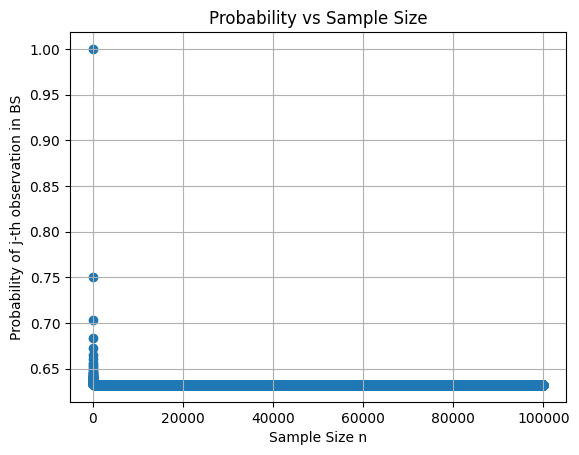

In [154]:
# (g)
import numpy as np
import matplotlib.pyplot as plt
    
n_values = np.arange(1, 100000)
probabilities = 1 - (1 - 1/n_values)**n_values

plt.scatter(n_values, probabilities)
plt.xlabel('Sample Size n')
plt.ylabel('Probability of j-th observation in BS')
plt.title('Probability vs Sample Size')
plt.grid()
plt.show()

We observe that the first point has probability equal to one, which makes sense because if we only have on observation it must be in the bootstrap sample. After, the probability starts decreasing until it reaches a plateau close to the value $ 0.632$.
The limit of the probability when $ n $ goes to infinity is well known:
$
\lim_{n \to \infty} \left( 1 - \frac{n-1}{n} \right)^n \iff 1 - \lim_{n \to \infty} \left( 1 - \frac{1}{n} \right)^n = 1 - e^{-1} \approx 1 - 0.36788 = 0.63212.
$

Let's try zooming in the plot above for smaller values of $n$ so we can better observe the approach to the asymptote.

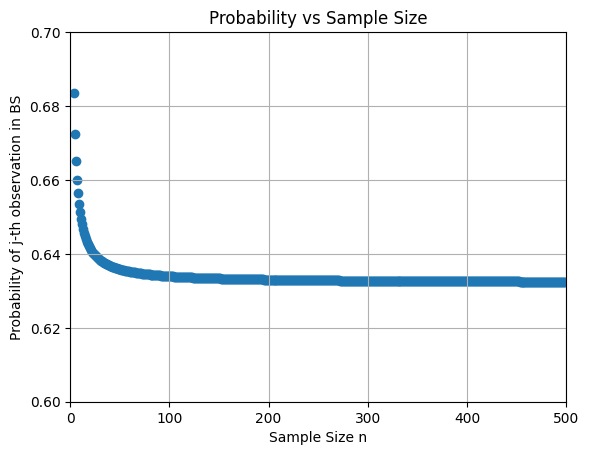

In [155]:

n_values = np.arange(1, 500)
probabilities = 1 - (1 - 1/n_values)**n_values

plt.scatter(n_values, probabilities)
plt.xlabel('Sample Size n')
plt.ylabel('Probability of j-th observation in BS')
plt.title('Probability vs Sample Size')
plt.xlim(0, 500)
plt.ylim(.6,.7)
plt.grid()
plt.show()


In [156]:
#(h)

import random

n = 100
N = 10000
count = 0

for _ in range(N):
    # True equals 1 in Python
    # choices(l, k=k) takes k samples from the list l with replacement
    count += 4 in random.choices(range(1,n+1), k=n) 

print(count/N)

0.6332


(array([ 2.,  7.,  5.,  8., 19., 18., 16., 18.,  5.,  2.]),
 array([0.6223 , 0.62448, 0.62666, 0.62884, 0.63102, 0.6332 , 0.63538,
        0.63756, 0.63974, 0.64192, 0.6441 ]),
 <BarContainer object of 10 artists>)

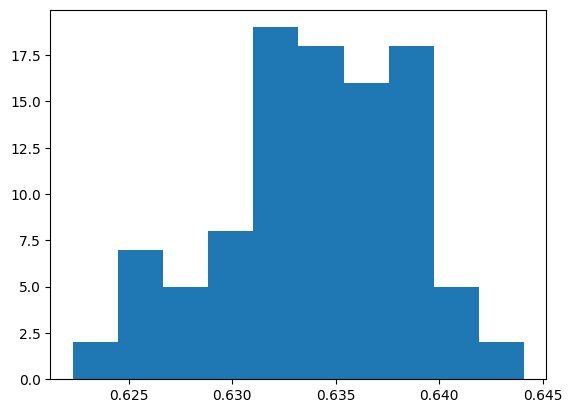

In [157]:
import numpy as np
x = []

for i in range(100):
    a = np.fromiter((4 in np.random.choice(100, 100, replace=True) for _ in range(N)), dtype=bool)
    x.append(np.mean(a)) 

plt.hist(x)

As expected, the value found is close to 0.63397, the value given by the formula. But it is an underestimate. If we repeat the calculation several times, we would expect approximately half the estimates to be an underestimate, and the other half to be an overestimate. Let's try it. So, for fun, we redo the calculation above a few more times (now with numpy) and do confirm this from the histogram below.

Question 5.5

In [158]:
#(a)
# Load the dataset
data=load_data("Default")

data['default'] = data['default'].apply(lambda x:1 if x=='Yes' else 0)

X = data[['income','balance']] # Features
y = data['default']  # Target variable

### Logistic Regression Model
np.random.seed(0)

lr = LogisticRegression()
Log_Model=lr.fit(X, y)
print(Log_Model.intercept_)
print(Log_Model.coef_)

# Fit logistic regression model
X = sm.add_constant(X)
Log_Model = sm.Logit(y, X)
Result = Log_Model.fit()
print(Result.summary())

[-11.54046792]
[[2.08089741e-05 5.64710265e-03]]
Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Sun, 27 Oct 2024   Pseudo R-squ.:                  0.4594
Time:                        00:49:19   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000    

In [159]:

# Part (b): Validation set approach
np.random.seed(42)
def validation_test_error(X, y):
    # Split the data into training and validation sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=np.random.randint(100))

    # Fit a logistic regression model
    model = LogisticRegression(solver='liblinear')
    model.fit(X_train, y_train)

    # Predict on the validation set
    y_pred = model.predict(X_test)

    # Compute validation error (1 - accuracy)
    error = 1 - accuracy_score(y_test, y_pred)
    return error

print(f"Validation Errors for 1 Splits: {validation_test_error(X, y)}")


Validation Errors for 1 Splits: 0.035499999999999976


In [160]:
# Part (c)
# Run the validation test error three times with different random splits
errors = [validation_test_error(X, y) for _ in range(3)]
average_error = np.mean(errors)

print(f"Validation Errors for 3 Splits: {errors}")
print(f"Average Validation Error: {average_error}")


Validation Errors for 3 Splits: [0.034499999999999975, 0.029000000000000026, 0.03249999999999997]
Average Validation Error: 0.031999999999999994


In [161]:

# Part (d): Adding the 'student' dummy variable

X_with_student = pd.concat([X, pd.get_dummies(data['student'], drop_first=True)], axis=1)

# Repeat the validation error calculation with 'student' variable included
errors_with_student = [validation_test_error(X_with_student, y)]

print(f"Validation Errors with 'student' for 1 Split: {errors_with_student}")


Validation Errors with 'student' for 1 Split: [0.033499999999999974]


Adding the student predictor reduces the test error rate (0.033499999999999974) compared to that in (b) (0.035499999999999976) but it is higher compared to the Average Validation Error: 0.031999999999999994.

Adding 

Question 5.6

In [162]:
#(a)
# Load the dataset
data=load_data("Default")

# Define the features (X) and target variable (y)
from ISLP.models import (ModelSpec as MS, summarize, poly)

X = data[['income','balance']] # Features
y = data['default']  # Target variable

In [163]:
### Logistic Regression Model
warnings.filterwarnings('ignore')
np.random.seed(0)

#using generalized linear models with statsmodel
mod1 = smf.glm(formula='default ~ income + balance', data=data, family=sm.families.Binomial(sm.families.links.logit())).fit() #create & fit model
print(mod1.summary()) #show results


                        Generalized Linear Model Regression Results                        
Dep. Variable:     ['default[No]', 'default[Yes]']   No. Observations:                10000
Model:                                         GLM   Df Residuals:                     9997
Model Family:                             Binomial   Df Model:                            2
Link Function:                               logit   Scale:                          1.0000
Method:                                       IRLS   Log-Likelihood:                -789.48
Date:                             Sun, 27 Oct 2024   Deviance:                       1579.0
Time:                                     00:49:19   Pearson chi2:                 6.95e+03
No. Iterations:                                  9   Pseudo R-squ. (CS):             0.1256
Covariance Type:                         nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-

Estimated standard errors for the coefficients associated with income and balance are 4.99e-06 and 0, respectively.

In [164]:
# (b)
warnings.filterwarnings('ignore')

def boot_fn(default):
    mod1 = smf.glm(formula='default ~ income + balance', data=default, family=sm.families.Binomial(sm.families.links.logit())).fit()
    coef_income = mod1.params[1]
    coef_balance = mod1.params[2]
    return [coef_income, coef_balance]

boot_fn(data)

[-2.0808975528986873e-05, -0.005647102950316487]

In [165]:
#(c)
# Number of bootstrap samples
n_bootstraps = 1000

# Bootstrap the coefficients
bootstrapped_coefs = np.array([boot_fn(data.sample(frac=1, replace=True)) for _ in range(n_bootstraps)])

# Calculate the standard errors of the coefficients
income_se = np.std(bootstrapped_coefs[:, 0])
balance_se = np.std(bootstrapped_coefs[:, 1])

print(f"Bootstrap Standard Error for 'income' coefficient: {income_se:.4f}")
print(f"Bootstrap Standard Error for 'balance' coefficient: {balance_se:.4f}")

Bootstrap Standard Error for 'income' coefficient: 0.0000
Bootstrap Standard Error for 'balance' coefficient: 0.0002


Estimated standard errors for the coefficients associated with income and balance are 0.0000 and 0.0002, respectively.

(d)

The Estimated standard error  obtained using the sm.GLM() function and using the bootstrap are almost the same.
